<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/Lab11_NLP_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing (NLP) Project

In [16]:
!pip install nltk wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string

### 1. NLTK Data Downloads

In [17]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

### 2. Dataset Loading and Initial Exploration

In [18]:
# Upload files in Colab first

amazon = pd.read_csv("amazon_cells_labelled.txt", sep='\t', header=None)
imdb = pd.read_csv("imdb_labelled.txt", sep='\t', header=None)
yelp = pd.read_csv("yelp_labelled.txt", sep='\t', header=None)

amazon.columns = ['text', 'label']
imdb.columns = ['text', 'label']
yelp.columns = ['text', 'label']

# Combine
df = pd.concat([amazon, imdb, yelp], ignore_index=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2748, 2)


,text,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


### 3. Sentiment Distribution

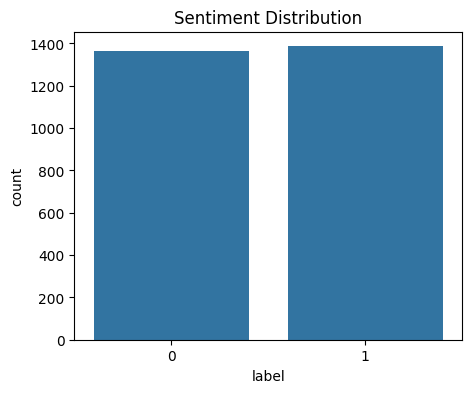

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

### 4. Demonstrating NLP Techniques on a Sample Review

In [20]:
sample = df['text'].iloc[0]
print("Sample Text:\n", sample)

Sample Text:
 So there is no way for me to plug it in here in the US unless I go by a converter.


#### 4.1 Tokenization

In [21]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(sample)
print(tokens)

['So', 'there', 'is', 'no', 'way', 'for', 'me', 'to', 'plug', 'it', 'in', 'here', 'in', 'the', 'US', 'unless', 'I', 'go', 'by', 'a', 'converter', '.']


#### 4.2 Stop Word Removal

In [22]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered = [w for w in tokens if w.lower() not in stop_words]
print(filtered)

['way', 'plug', 'US', 'unless', 'go', 'converter', '.']


#### 4.3 Lemmatization

In [23]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

lemmatized_sample = [lemmatizer.lemmatize(w) for w in filtered]
print(lemmatized_sample)

['way', 'plug', 'US', 'unless', 'go', 'converter', '.']


#### 4.4 Stemming

In [24]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

stemmed = [stemmer.stem(w) for w in filtered]
print(stemmed)

['way', 'plug', 'us', 'unless', 'go', 'convert', '.']


#### 4.5 Parts of Speech (POS) Tagging

In [25]:
pos_tags = nltk.pos_tag(filtered)
print(pos_tags)

[('way', 'NN'), ('plug', 'NN'), ('US', 'NNP'), ('unless', 'IN'), ('go', 'VBP'), ('converter', 'NN'), ('.', '.')]


#### 4.6 Named Entity Recognition (NER)

In [26]:
from nltk import ne_chunk

ner = ne_chunk(pos_tags)
print(ner)

(S
  way/NN
  plug/NN
  (ORGANIZATION US/NNP)
  unless/IN
  go/VBP
  converter/NN
  ./.)


### 5. Analyzing the Full Corpus

In [27]:
all_text = " ".join(df['text'])

tokens = word_tokenize(all_text.lower())

#### 5.1 Preprocessing for Full Corpus Analysis

In [28]:
stop_words = set(stopwords.words('english'))

filtered_tokens = [
    w for w in tokens
    if w.isalpha() and w not in stop_words
]

In [29]:
lemmatized = [lemmatizer.lemmatize(w) for w in filtered_tokens]

#### 5.2 Frequency Distribution

<Axes: xlabel='Samples', ylabel='Counts'>

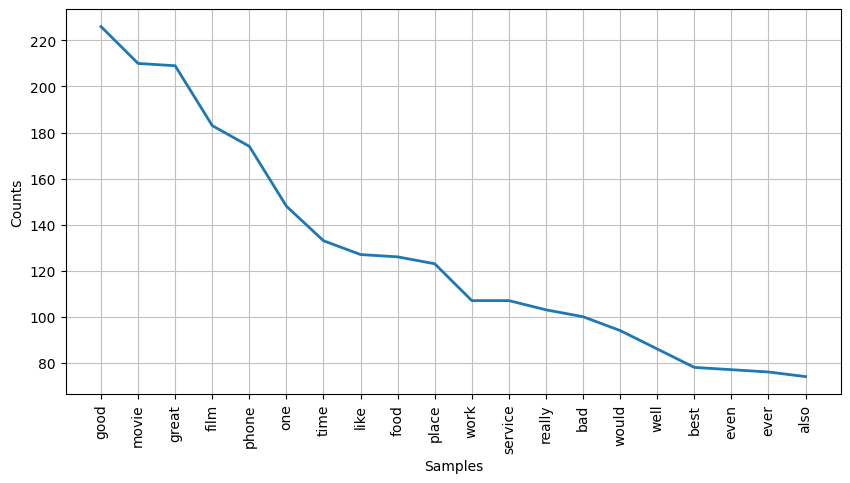

In [30]:
from nltk import FreqDist

fdist = FreqDist(lemmatized)

plt.figure(figsize=(10,5))
fdist.plot(20)

#### 5.3 Dispersion Plot

<Figure size 1000x500 with 0 Axes>

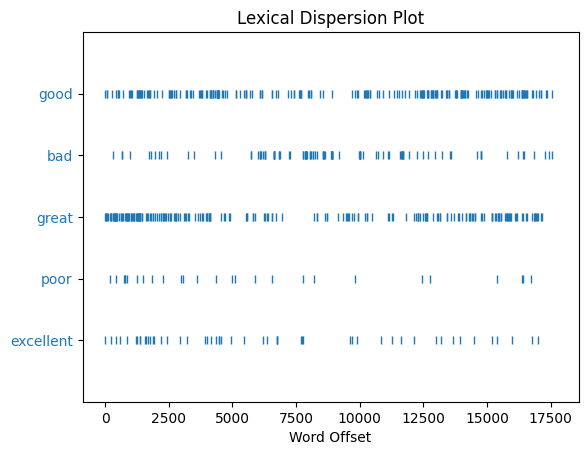

In [31]:
text_obj = nltk.Text(lemmatized)

plt.figure(figsize=(10,5))
text_obj.dispersion_plot(["good", "bad", "great", "poor", "excellent"])

#### 5.4 Collocation Analysis

In [33]:
text_obj.collocations(20)

customer service; waste time; waste money; would recommend; highly
recommend; sound quality; battery life; anytime soon; cell phone; ever
seen; ray charles; work great; bluetooth headset; piece junk; year
ago; one best; zero star; los angeles; stay away; car charger
